In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [4]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print(model.invoke("I want to know about Langgraph ?"))
except:
  print("Something went wrong")

content='LangGraph is a Python library built on top of LangChain that enables you to build **stateful, multi-actor applications with explicit control flow and cycles** for your Language Model (LLM) workflows.\n\nThink of it as a way to define and manage complex, multi-step interactions, especially useful for building sophisticated AI agents that can self-correct, loop through steps, use tools conditionally, and engage in more dynamic reasoning.\n\n## The Core Idea: Finite State Machines for LLMs\n\nAt its heart, LangGraph allows you to model your LLM application as a **finite state machine (FSM)**. This means you define:\n\n1.  **A Shared State:** This is the memory or context that gets passed between different steps of your application. It holds all relevant information (e.g., conversational history, tool outputs, current task, flags).\n2.  **Nodes:** These are the "steps" or "actions" in your workflow. A node can be:\n    *   An LLM call (e.g., `ChatOpenAI`).\n    *   A tool invocati

### Pydantic Schema

In [3]:
from pydantic import BaseModel,Field

class graph_schema(BaseModel):
    topic : str = Field(description="The topic of the graph")
    linkedin : str = Field(description="The LinkedIn Post Content")
    insta : str = Field(description="The curated Instagram Post Content")
    twitter: str = Field(description="The curated Twitter Post Content")


In [14]:
def create_post_insta(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#We can also refer the pydantic model as dictionary(like we refered in 1_basics.ipynb)
    state=state.model_dump()

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a Instagram post about {topic}. Keep the tone casual and engaging").content

#Update the state with the generated post
    state['insta'] = post

    return {'insta': post}

def create_post_twitter(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#We can also refer the pydantic model as dictionary(like we refered in 1_basics.ipynb)
    state=state.model_dump()

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

#Update the state with the generated post
    state['twitter'] = post

    return {'twitter': post}

def create_post_linkedin(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#We can also refer the pydantic model as dictionary(like we refered in 1_basics.ipynb)
    state=state.model_dump()

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative").content

#Update the state with the generated post
    state['linkedin'] = post

    return {'linkedin': post}

In [15]:
from langgraph.graph import StateGraph, START, END 

graph = StateGraph(graph_schema)

graph.add_node("create_post_linkedin",create_post_linkedin)
graph.add_node("create_post_insta",create_post_insta)
graph.add_node("create_post_twitter",create_post_twitter)

graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_linkedin")
graph.add_edge(START, "create_post_twitter")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_linkedin", END)
graph.add_edge("create_post_twitter", END)



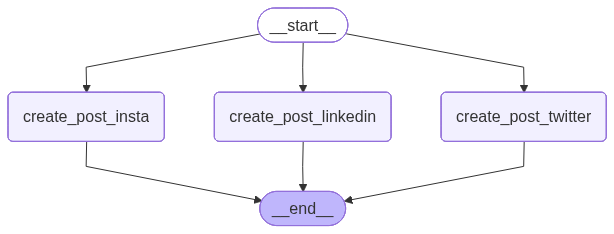

In [16]:
from IPython.display import Image, display

my_pydantic_graph=graph.compile()

Image(my_pydantic_graph.get_graph().draw_mermaid_png())

In [17]:
my_pydantic_graph.invoke(
    {"topic":"Greatness of NTR",
     "insta":"",
     "twitter":"",
     "linkedin":""
    }

)

{'topic': 'Greatness of NTR',
 'linkedin': "Here's a LinkedIn post recognizing the greatness of NTR, keeping the tone professional and informative:\n\n---\n\n**Subject: Exploring the Enduring Legacy of a True Visionary: Nandamuri Taraka Rama Rao (NTR)**\n\nToday, I wanted to reflect on the monumental impact of Nandamuri Taraka Rama Rao (NTR), a name synonymous with greatness in Indian cinema and politics. His journey is a powerful testament to how one individual can profoundly shape a culture and a nation.\n\nNTR's brilliance first shone in the realm of cinema. As an actor, director, and producer, he starred in over 300 films, mastering roles from mythological deities to common man characters. He wasn't just entertaining; he became a cultural icon, embodying the aspirations and values of the Telugu people. His portrayal of gods and heroes etched him into the hearts of millions, making him a household name and a symbol of Telugu pride long before his political foray.\n\nHis transition i